In [1]:
import os
import leafmap

In [2]:
# Use the TiTiler demo endpoint. Replace this if needed.
os.environ["TITILER_ENDPOINT"] = "https://giswqs-titiler-endpoint.hf.space"

In [3]:
Map = leafmap.Map()
Map

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# Updated S3 public base URL
#base_url = "https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/NG/2025/5/21/0" #does not exist
base_url = "https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/NG/2025/5/5/0"
# Bands to download
bands = {
    "B08": "B08.jp2",  # NIR
    "B11": "B11.jp2",  # SWIR
}

# Make a folder to save bands
os.makedirs("s2_bands", exist_ok=True)

# Download each band from S3
for band_name, filename in bands.items():
    url = f"{base_url}/{filename}"
    print(f"Downloading {url}")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(f"s2_bands/{filename}", 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"✅ Downloaded {filename}")
    else:
        print(f"❌ Failed to download {filename} — HTTP {response.status_code}")


✅ Downloaded B08.jp2
✅ Downloaded B11.jp2


B08 shape: (10980, 10980)
B11 shape before resampling: (5490, 5490)
B11 shape after resampling: (10980, 10980)


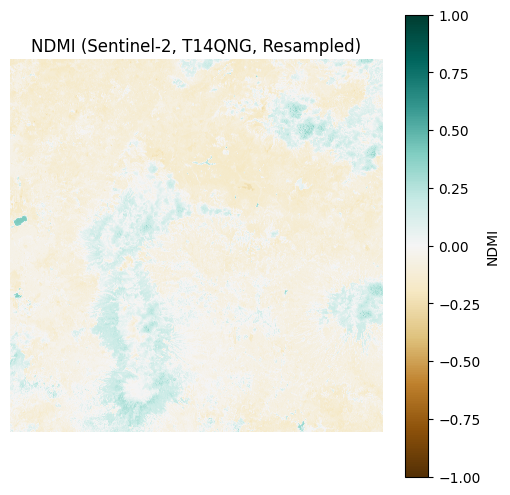

In [5]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import os

# Read B08 (10m NIR)
with rasterio.open("s2_bands/B08.jp2") as src_nir:
    B08 = src_nir.read(1).astype("float32")
    nir_profile = src_nir.profile
    print("B08 shape:", B08.shape)

# Read B11 (20m SWIR)
with rasterio.open("s2_bands/B11.jp2") as src_swir:
    B11_orig = src_swir.read(1).astype("float32")
    swir_profile = src_swir.profile
    print("B11 shape before resampling:", B11_orig.shape)

# Prepare empty array to match B08 shape
B11_resampled = np.empty_like(B08, dtype="float32")

# Reproject (resample) B11 to B08's shape/resolution
reproject(
    source=B11_orig,
    destination=B11_resampled,
    src_transform=src_swir.transform,
    src_crs=src_swir.crs,
    dst_transform=src_nir.transform,
    dst_crs=src_nir.crs,
    resampling=Resampling.bilinear
)

print("B11 shape after resampling:", B11_resampled.shape)




# Compute NDMI
myNdmiMax = .1
myNdmiMin = -.1
ndmi = np.where((B08 + B11_resampled) == 0, 0, (B08 - B11_resampled) / (B08 + B11_resampled))

# Plot NDMI
plt.figure(figsize=(6, 6))
plt.imshow(ndmi, cmap='BrBG', vmin=-1, vmax=1)
plt.colorbar(label="NDMI")
plt.title("NDMI (Sentinel-2, T14QNG, Resampled)")
plt.axis('off')
plt.show()


In [6]:
# Display with Leafmap
Map = leafmap.Map(center=[19.777411, -96.870102], zoom=18)
#Map.add_raster(tif_path, layer_name="NDMI", opacity=0.4)
Map.add_basemap("OpenStreetMap")
Map.set_center(lon=-96.870102, lat=19.777411, zoom=18)  # Veracruz

Map

OpenStreetMap has been already added before.


Map(center=[19.777411, -96.870102], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [7]:
import leafmap

Map = leafmap.Map(center=[19.777411, -96.870102], zoom=12)
Map.add_raster("ndmi_reprojected.tif", layer_name="NDMI", opacity=0.9)
#Map.add_basemap("OpenStreetMap")
Map

Map(center=[19.398815499999998, -98.4757545], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

In [9]:
# Re-run the previous code after reset

import os
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import transform
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from tempfile import NamedTemporaryFile
from datetime import datetime, timedelta

# Point of interest (Veracruz)
lat, lon = 19.777411, -96.870102

# Sentinel-2 tile metadata
tile = {
    "utm_zone": "14",
    "latitude_band": "Q",
    "grid_square": "NG"
}
print ("check 11")

def generate_date_range(start: str, end: str, fmt: str = "%Y-%m-%d") -> list:
    """
    Generate a list of consecutive date strings from start to end (inclusive).
    
    Args:
        start (str): Start date as 'YYYY-MM-DD'
        end (str): End date as 'YYYY-MM-DD'
        fmt (str): Date format for output (default: '%Y-%m-%d')
        
    Returns:
        List[str]: List of date strings
    """
    start_date = datetime.strptime(start, fmt)
    end_date = datetime.strptime(end, fmt)
    dates = []
    current = start_date
    while current <= end_date:
        dates.append(current.strftime(fmt))
        current += timedelta(days=1)
    return dates
    

# Dates you want to sample NDMI from (you can extend this list)
dates = [
    "2025-05-01",
    "2025-05-02",
    "2025-05-03",
    "2025-05-04",
    "2025-05-05",
    "2025-05-06",
    "2025-05-07",
    "2025-05-08",
    "2025-05-09",
    "2025-05-10",
    "2025-05-11",
    "2025-05-12",
    "2025-05-13",
    "2025-05-14",
    "2025-05-15",
    "2025-05-16",
    "2025-05-17",
    "2025-05-18",
    "2025-05-19",
    "2025-05-20",
    "2025-05-22",
    "2025-05-23",
    "2025-05-25",
    "2025-05-30",
    "2025-06-04",
    "2025-06-09",
    "2025-06-14",
    "2025-06-19",
    "2025-06-24",
    "2025-06-29"
    #"2025-05-21" # does not exist
]

dates = generate_date_range("2025-05-01", "2025-06-30",  "%Y-%m-%d")
print("dates = ",dates)

# Output lists
ndmi_values = []
valid_dates = []

# Prepare folder
os.makedirs("s2_point_series", exist_ok=True)

def download_band(date, band):
    y, m, d = date.split("-")

    #base_url = f"https://roda.sentinel-hub.com/sentinel-s2-l1c/tiles/{tile['utm_zone']}/{tile['latitude_band']}/{tile['grid_square']}/{y}/{int(m)}/{int(d)}/0/{band}.jp2"
    base_url = f"https://sentinel-s2-l1c.s3.amazonaws.com/tiles/{tile['utm_zone']}/{tile['latitude_band']}/{tile['grid_square']}/{y}/{int(m)}/{int(d)}/0/{band}.jp2"

    print("base_url = ",base_url )
    filename = f"s2_point_series/{date}_{band}.jp2"
    print("filename = ",filename)
    #filename = f"s2_point_series/{date}_{band}.jp2"
    if not os.path.exists(filename):
        print("check 10")
        print("base_url ",base_url)
        r = requests.get(base_url, stream=True)
        print ("r.status_code ",r.status_code)
        if r.status_code == 200:
            with open(filename, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        else:
            print("returning None")
            return None
    return filename if os.path.exists(filename) else None


"""def get_pixel_from_latlon(bounds, lat, lon, shape):
    west, south, east, north = bounds
    height, width = shape
    if not (south <= lat <= north and west <= lon <= east):
        print("out of bounds")
        return None, None
    row = int((north - lat) / ((north - south) / height))
    col = int((lon - west) / ((east - west) / width))
    return row, col"""

from rasterio.warp import reproject, Resampling


# Sample NDMI at the given point
for date in dates:
    print("processing date ",date)
    b08_path = download_band(date, "B08")
    b11_path = download_band(date, "B11")
    if not b08_path or not b11_path:
        continue

    try:
        with rasterio.open(b08_path) as src_b08, rasterio.open(b11_path) as src_b11:
            # Transform point to image coordinates
            #point_x, point_y = transform('EPSG:4326', src_b08.crs, [lon], [lat])
            #row, col = src_b08.index(point_x[0], point_y[0])
            #19.777411, -96.870102
            bounds = (-96.98, 19.53, -96.38, 20.03)
            shape = (10980, 10980)

            row,col = Utils.get_pixel_from_latlon(bounds, lat, lon, shape)

            b08 = src_b08.read(1)[row, col].astype(float)


            b11_data = src_b11.read(1)
            resampled_b11 = np.empty((10980, 10980), dtype="float32")
            reproject(
                source=b11_data,
                destination=resampled_b11,
                src_transform=src_b11.transform,
                src_crs=src_b11.crs,
                dst_transform=src_b08.transform,
                dst_crs=src_b08.crs,
                resampling=Resampling.bilinear
            )
            b11 = resampled_b11[row, col]

            
            
            print("b08 = ",b08)
            print("b11 = ",b11)

            if (b08 + b11) != 0:
                ndmi = (b08 - b11) / (b08 + b11)
                ndmi_values.append(ndmi)
                valid_dates.append(datetime.strptime(date, "%Y-%m-%d"))
    except Exception as e:
        print(f"Skipping {date} due to error: {e}")

# Plot NDMI vs Time
if valid_dates and ndmi_values:
    plt.figure(figsize=(10, 5))
    plt.plot(valid_dates, ndmi_values, marker='o', linestyle='-')
    plt.xlabel("Date")
    plt.ylabel("NDMI")
    plt.title("NDMI Time Series at Point (AWS Sentinel-2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No NDMI values extracted. Try different dates or location.")



check 11
dates =  ['2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04', '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09', '2025-05-10', '2025-05-11', '2025-05-12', '2025-05-13', '2025-05-14', '2025-05-15', '2025-05-16', '2025-05-17', '2025-05-18', '2025-05-19', '2025-05-20', '2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30', '2025-05-31', '2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05', '2025-06-06', '2025-06-07', '2025-06-08', '2025-06-09', '2025-06-10', '2025-06-11', '2025-06-12', '2025-06-13', '2025-06-14', '2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28', '2025-06-29', '2025-06-30']
processing date  2025-05-01
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/NG/2025/5/1/0/B08.jp2
filename =  s